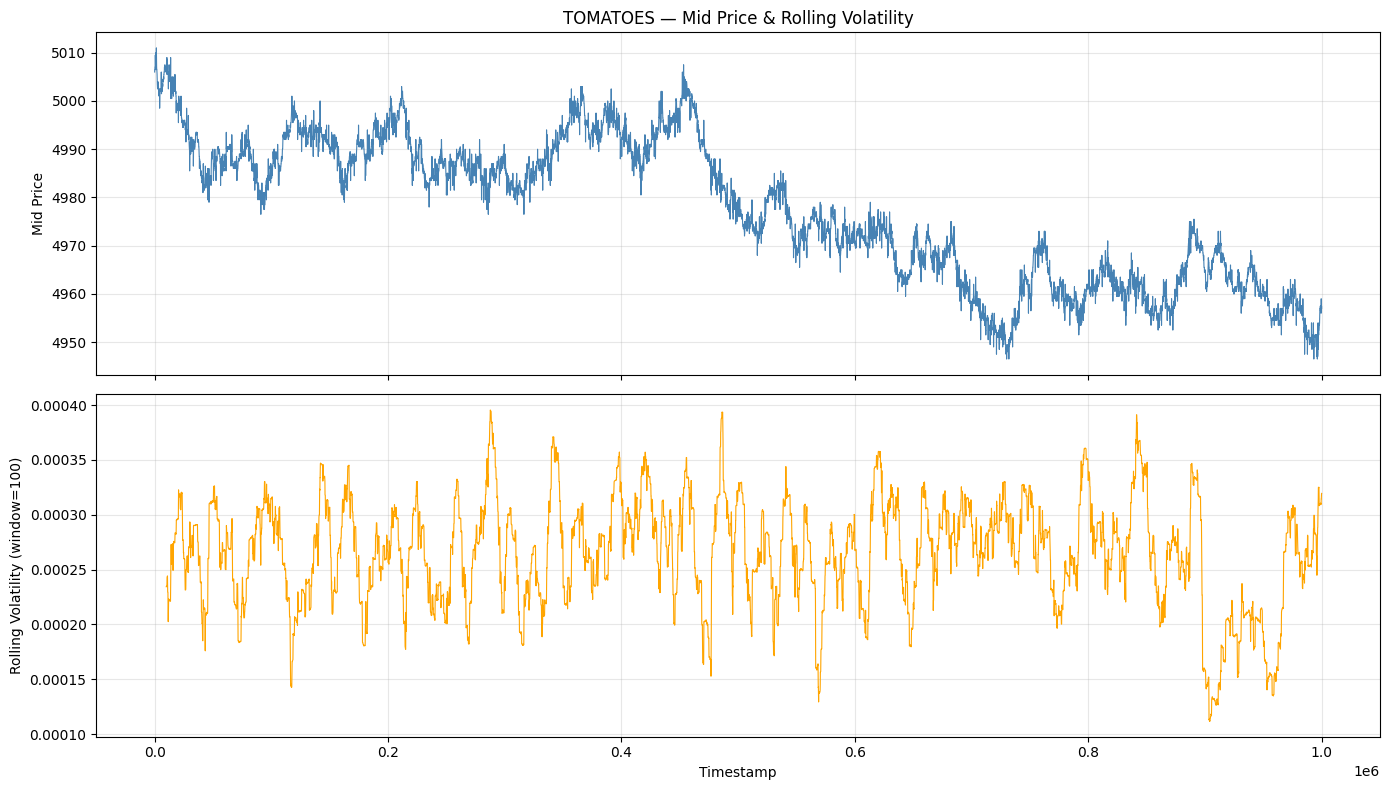

=== Rolling Volatility Summary ===
Mean vol:   0.000265
Max vol:    0.000396
Min vol:    0.000112
Std of vol: 0.000048

=== High Volatility Periods (top 5%) ===
Threshold (95th percentile): 0.000339
 timestamp  mid_price  rolling_vol
    141900     4995.5     0.000346
    142000     4994.5     0.000347
    142100     4993.5     0.000347
    142200     4993.5     0.000347
    142300     4994.0     0.000347
    142400     4994.5     0.000347
    142500     4994.0     0.000347
    142600     4994.5     0.000347
    142700     4994.5     0.000346
    142800     4994.0     0.000346
    142900     4993.5     0.000346
    143000     4993.5     0.000346
    143100     4993.0     0.000346
    143200     4992.5     0.000346
    143300     4992.5     0.000346
    143400     4992.5     0.000346
    143500     4992.5     0.000346
    143600     4992.5     0.000345
    143700     4992.5     0.000345
    143800     4992.0     0.000345


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('Data (Raw CSV)/prices_round_0_day_-1.csv', sep=';')

# Filter for TOMATOES only
tomatoes = df[df['product'] == 'TOMATOES'].copy().reset_index(drop=True)

# Calculate log returns from mid price
tomatoes['log_return'] = np.log(tomatoes['mid_price'] / tomatoes['mid_price'].shift(1))

# Rolling volatility — standard deviation of log returns over a window
# Window = 100 timestamps (~10 seconds of data)
WINDOW = 100
tomatoes['rolling_vol'] = tomatoes['log_return'].rolling(window=WINDOW).std()

# Each timestamp is 100ms, so there are 10 per second
# tomatoes['rolling_vol_annualised'] = tomatoes['rolling_vol'] * np.sqrt(10 * 60 * 60 * 24 * 365)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(tomatoes['timestamp'], tomatoes['mid_price'], color='steelblue', linewidth=0.8)
ax1.set_ylabel('Mid Price')
ax1.set_title('TOMATOES — Mid Price & Rolling Volatility')
ax1.grid(True, alpha=0.3)

ax2.plot(tomatoes['timestamp'], tomatoes['rolling_vol'], color='orange', linewidth=0.8)
ax2.set_ylabel(f'Rolling Volatility (window={WINDOW})')
ax2.set_xlabel('Timestamp')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary stats
print("=== Rolling Volatility Summary ===")
print(f"Mean vol:   {tomatoes['rolling_vol'].mean():.6f}")
print(f"Max vol:    {tomatoes['rolling_vol'].max():.6f}")
print(f"Min vol:    {tomatoes['rolling_vol'].dropna().min():.6f}")
print(f"Std of vol: {tomatoes['rolling_vol'].std():.6f}")
print()
print("=== High Volatility Periods (top 5%) ===")
threshold = tomatoes['rolling_vol'].quantile(0.95)
high_vol = tomatoes[tomatoes['rolling_vol'] > threshold][['timestamp', 'mid_price', 'rolling_vol']]
print(f"Threshold (95th percentile): {threshold:.6f}")
print(high_vol.head(20).to_string(index=False))

In [3]:
df = pd.read_csv('Data (Raw CSV)/prices_round_0_day_-1.csv', sep=';')
tomatoes = df[df['product'] == 'TOMATOES'].copy().reset_index(drop=True)

prices    = tomatoes['mid_price'].values
bid_vol   = tomatoes['bid_volume_1'].values
ask_vol   = tomatoes['ask_volume_1'].values
bid_price = tomatoes['bid_price_1'].values
ask_price = tomatoes['ask_price_1'].values
timestamps = tomatoes['timestamp'].values

print("=" * 60)
print("TOMATOES DATA SUMMARY")
print("=" * 60)
print(f"Rows:           {len(tomatoes)}")
print(f"Mid price mean: {prices.mean():.2f}")
print(f"Mid price std:  {prices.std():.4f}")
print(f"Mid price min:  {prices.min():.2f}")
print(f"Mid price max:  {prices.max():.2f}")
print()

TOMATOES DATA SUMMARY
Rows:           10000
Mid price mean: 4977.57
Mid price std:  14.5778
Mid price min:  4946.50
Mid price max:  5011.00



In [4]:
print("=" * 60)
print("1. VOLUME-WEIGHTED MID PRICE")
print("=" * 60)

vwap_mid = (bid_price * ask_vol + ask_price * bid_vol) / (bid_vol + ask_vol)

vwap_error = np.abs(prices - vwap_mid)
print(f"Mean error vs mid price: {vwap_error.mean():.4f}")
print(f"Max error vs mid price:  {vwap_error.max():.4f}")
print(f"VWAP mid mean:           {vwap_mid.mean():.4f}")
print()

1. VOLUME-WEIGHTED MID PRICE
Mean error vs mid price: 0.0689
Max error vs mid price:  3.0000
VWAP mid mean:           4977.5621



In [5]:
print("=" * 60)
print("2. EMA ALPHA COMPARISON")
print("=" * 60)

alphas = [0.01, 0.02, 0.05, 0.10, 0.20, 0.50]
ema_results = {}

for alpha in alphas:
    ema = np.zeros(len(prices))
    ema[0] = prices[0]
    for i in range(1, len(prices)):
        ema[i] = alpha * vwap_mid[i] + (1 - alpha) * ema[i - 1]

    mean_err = np.abs(prices - ema).mean()
    max_err  = np.abs(prices - ema).max()
    lag      = 1 / alpha  # approximate lag in steps
    ema_results[alpha] = ema

    print(f"alpha={alpha:.2f}  mean_error={mean_err:.4f}  max_error={max_err:.4f}  approx_lag={lag:.0f} steps")

print()
best_alpha = min(alphas, key=lambda a: np.abs(prices - ema_results[a]).mean())
print(f"Best alpha (lowest mean error): {best_alpha}")
print()



2. EMA ALPHA COMPARISON
alpha=0.01  mean_error=2.7861  max_error=12.6335  approx_lag=100 steps
alpha=0.02  mean_error=2.0770  max_error=10.9197  approx_lag=50 steps
alpha=0.05  mean_error=1.3684  max_error=7.8914  approx_lag=20 steps
alpha=0.10  mean_error=0.9978  max_error=6.0660  approx_lag=10 steps
alpha=0.20  mean_error=0.7233  max_error=4.8486  approx_lag=5 steps
alpha=0.50  mean_error=0.4066  max_error=4.0950  approx_lag=2 steps

Best alpha (lowest mean error): 0.5



In [6]:
print("=" * 60)
print("3. ROLLING MEAN WINDOW COMPARISON")
print("=" * 60)

windows = [10, 25, 50, 100, 200, 500]
rolling_results = {}

for w in windows:
    roll = pd.Series(vwap_mid).rolling(w).mean().values
    valid = ~np.isnan(roll)
    mean_err = np.abs(prices[valid] - roll[valid]).mean()
    max_err  = np.abs(prices[valid] - roll[valid]).max()
    rolling_results[w] = roll
    print(f"window={w:4d}  mean_error={mean_err:.4f}  max_error={max_err:.4f}")

print()

3. ROLLING MEAN WINDOW COMPARISON
window=  10  mean_error=0.8790  max_error=5.5900
window=  25  mean_error=1.2732  max_error=7.1233
window=  50  mean_error=1.7517  max_error=9.2562
window= 100  mean_error=2.4093  max_error=12.8020
window= 200  mean_error=3.3102  max_error=14.0640
window= 500  mean_error=4.3724  max_error=16.4195



In [7]:
print("=" * 60)
print("4. DEVIATION ANALYSIS (using best EMA)")
print("=" * 60)

best_ema = ema_results[best_alpha]
deviation = prices - best_ema

print(f"Deviation mean:  {deviation.mean():.4f}")
print(f"Deviation std:   {deviation.std():.4f}")
print(f"Deviation min:   {deviation.min():.4f}")
print(f"Deviation max:   {deviation.max():.4f}")
print()

# How often price deviates enough to trade
for threshold in [1, 2, 3, 5, 8, 10]:
    pct_buy  = (deviation < -threshold).mean() * 100
    pct_sell = (deviation > +threshold).mean() * 100
    print(f"threshold=±{threshold:2d}  buy signal: {pct_buy:.1f}% of time  sell signal: {pct_sell:.1f}% of time")

print()

4. DEVIATION ANALYSIS (using best EMA)
Deviation mean:  0.0008
Deviation std:   0.6565
Deviation min:   -3.3595
Deviation max:   4.0950

threshold=± 1  buy signal: 4.2% of time  sell signal: 4.4% of time
threshold=± 2  buy signal: 1.9% of time  sell signal: 1.5% of time
threshold=± 3  buy signal: 0.0% of time  sell signal: 0.1% of time
threshold=± 5  buy signal: 0.0% of time  sell signal: 0.0% of time
threshold=± 8  buy signal: 0.0% of time  sell signal: 0.0% of time
threshold=±10  buy signal: 0.0% of time  sell signal: 0.0% of time



In [8]:
print("=" * 60)
print("5. SIMPLE BACKTEST (spread = 2, position limit = 20)")
print("=" * 60)

LIMIT = 20
SPREAD = 2

for threshold in [2, 3, 5, 8, 10]:
    pos  = 0
    pnl  = 0
    cash = 0

    for i in range(len(prices)):
        fv  = best_ema[i]
        mid = prices[i]
        dev = mid - fv

        # Buy signal — price below fair value
        if dev < -threshold and pos < LIMIT:
            buy_qty = min(5, LIMIT - pos)
            buy_px  = mid - SPREAD   # passive quote below mid
            cash   -= buy_px * buy_qty
            pos    += buy_qty

        # Sell signal — price above fair value
        elif dev > threshold and pos > -LIMIT:
            sell_qty = min(5, LIMIT + pos)
            sell_px  = mid + SPREAD  # passive quote above mid
            cash    += sell_px * sell_qty
            pos     -= sell_qty

    # Mark to market at end
    final_pnl = cash + pos * prices[-1]
    print(f"threshold=±{threshold:2d}  final_pnl={final_pnl:10.0f}  final_pos={pos:4d}")

print()

5. SIMPLE BACKTEST (spread = 2, position limit = 20)
threshold=± 2  final_pnl=      7598  final_pos=   5
threshold=± 3  final_pnl=       948  final_pos= -20
threshold=± 5  final_pnl=         0  final_pos=   0
threshold=± 8  final_pnl=         0  final_pos=   0
threshold=±10  final_pnl=         0  final_pos=   0



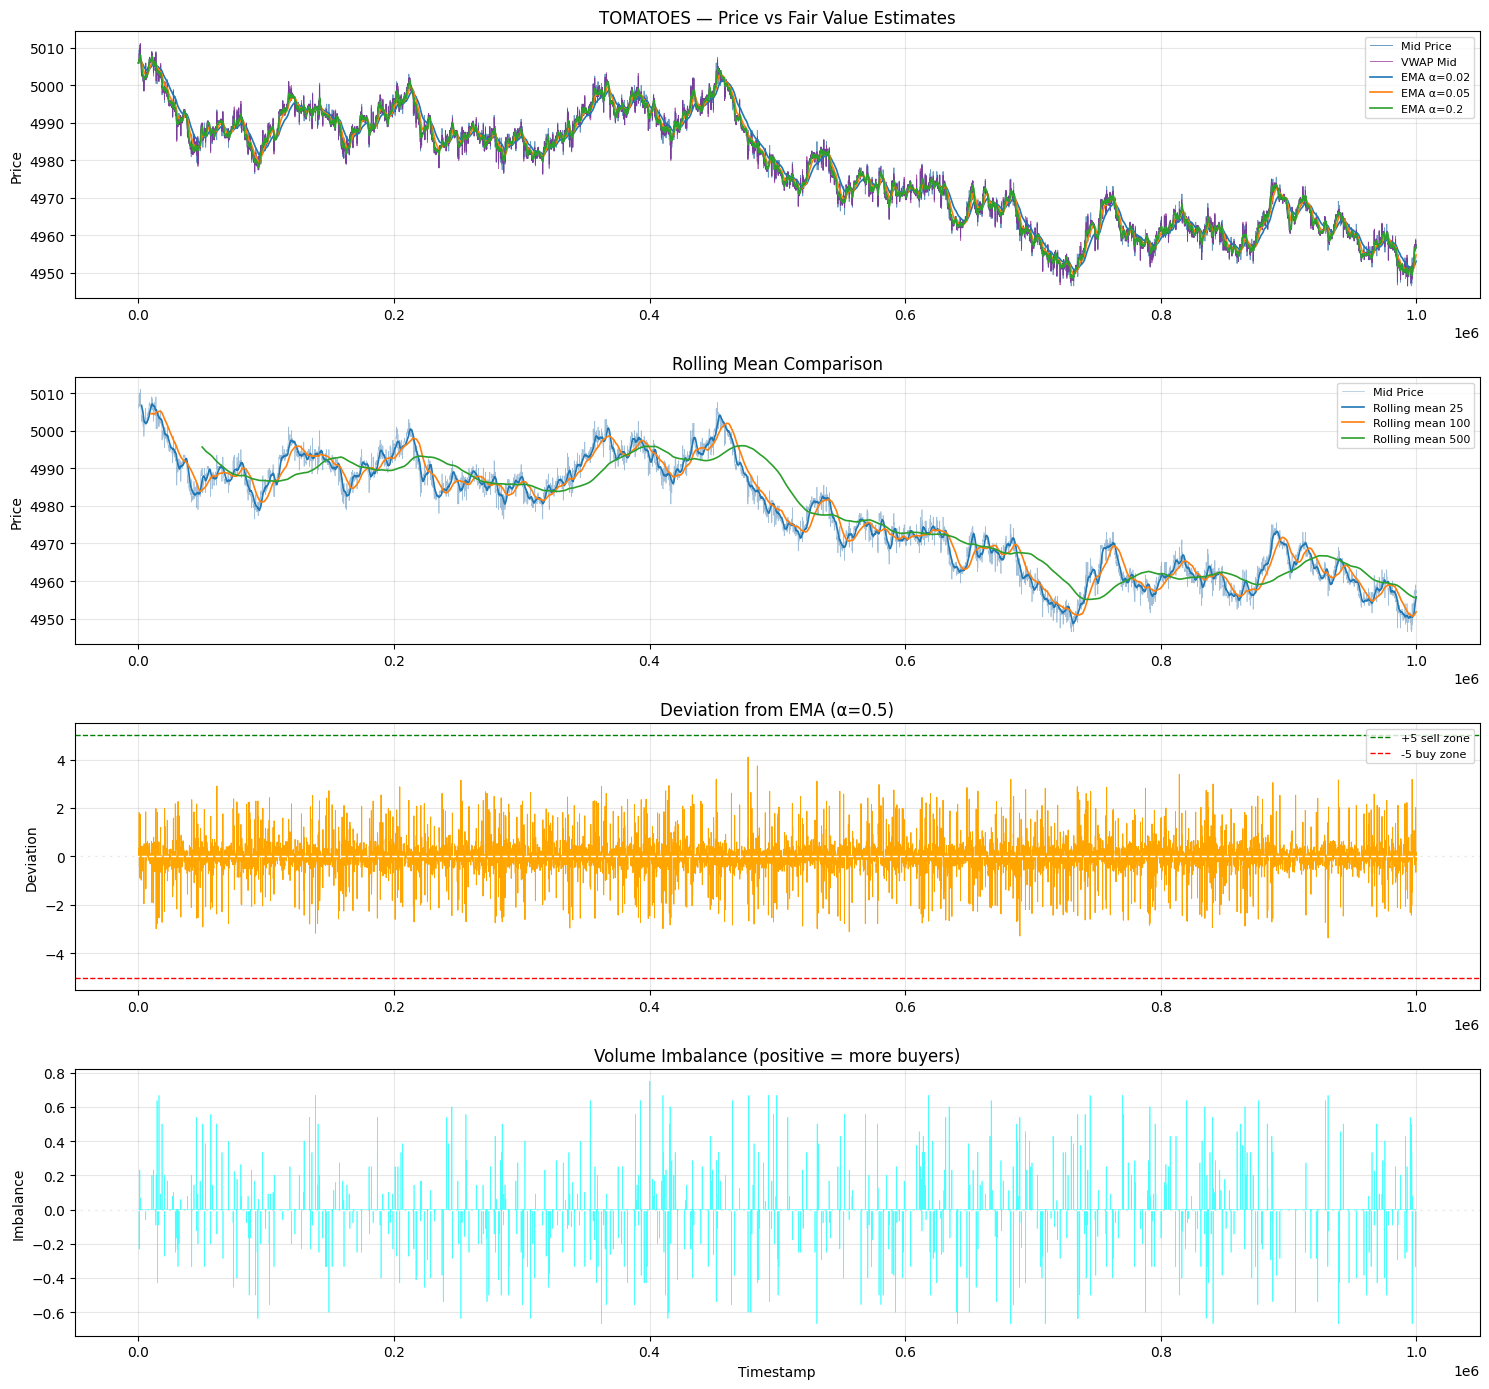

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(15, 14))

# Plot 1: price + EMAs
axes[0].plot(timestamps, prices, color='steelblue', linewidth=0.7, label='Mid Price', alpha=0.8)
axes[0].plot(timestamps, vwap_mid, color='purple', linewidth=0.7, label='VWAP Mid', alpha=0.6)
for alpha in [0.02, 0.05, 0.20]:
    axes[0].plot(timestamps, ema_results[alpha], linewidth=1.2, label=f'EMA α={alpha}')
axes[0].set_title('TOMATOES — Price vs Fair Value Estimates')
axes[0].set_ylabel('Price')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2: rolling means
axes[1].plot(timestamps, prices, color='steelblue', linewidth=0.5, alpha=0.5, label='Mid Price')
for w in [25, 100, 500]:
    axes[1].plot(timestamps, rolling_results[w], linewidth=1.2, label=f'Rolling mean {w}')
axes[1].set_title('Rolling Mean Comparison')
axes[1].set_ylabel('Price')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Plot 3: deviation from best EMA
axes[2].plot(timestamps, deviation, color='orange', linewidth=0.7)
axes[2].axhline(0,  color='white', linewidth=1, linestyle='--')
axes[2].axhline(5,  color='green', linewidth=1, linestyle='--', label='+5 sell zone')
axes[2].axhline(-5, color='red',   linewidth=1, linestyle='--', label='-5 buy zone')
axes[2].fill_between(timestamps, deviation, 0, where=(deviation > 5),  color='green', alpha=0.3)
axes[2].fill_between(timestamps, deviation, 0, where=(deviation < -5), color='red',   alpha=0.3)
axes[2].set_title(f'Deviation from EMA (α={best_alpha})')
axes[2].set_ylabel('Deviation')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

# Plot 4: volume imbalance
vol_imbalance = (bid_vol - ask_vol) / (bid_vol + ask_vol)
axes[3].plot(timestamps, vol_imbalance, color='cyan', linewidth=0.5, alpha=0.7)
axes[3].axhline(0, color='white', linewidth=1, linestyle='--')
axes[3].set_title('Volume Imbalance (positive = more buyers)')
axes[3].set_ylabel('Imbalance')
axes[3].set_xlabel('Timestamp')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
